# Feature analysis — `trade_rate_surge`

This notebook follows the project's feature-analysis **method** (copy of the `price_dislocation`
template, sibling to `volume_surge` and `mid_rate_surge`) on a new feature: **`trade_rate_surge`** —
a fast/slow ratio of a venue's **trade rate** (trades per second). The text says what to do and why;
the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and
**byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best buy and
best sell quote.) The next section recaps the model these features feed.

**The feature, in one line.** A venue's **trade rate** is how often *that venue* prints a trade, per
second. Smooth that rate two ways — a **fast** EMA and a **slow** EMA — and take the ratio:

`trade_rate_surge(ex; fast, slow) = trade_rate(ex, fast) / trade_rate(ex, slow)`

A ratio above 1 means that venue is trading *faster than its own baseline* right now — a trade-tempo
**surge**; below 1, a lull. The hypothesis is that a surge **predicts intensity**: when a venue starts
trading quickly, more byb mid-moves are about to follow. This reuses the **same `trade_rate(N)` raw
atom** as `trade_rate_normalised` (venue trades/sec, EMA span `N`) — here as a dimensionless fast/slow
ratio, so **no yardstick division is needed**.

**This is a per-exchange feature (like the template's dislocation gap).** Exactly as `price_dislocation`
computes a gap for *each* non-byb venue, and `mid_rate_surge` a surge for each venue, we compute a
trade-rate surge for **each** venue — byb, okx **and** bin — each from that venue's OWN trades, and ask
whether it predicts **byb's** next move. The byb leg is the *target's own* trade tempo; the okx/bin legs
are **cross-venue** trade-tempo lead/lag.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the optimized build really computes what we think it does (bit-exact vs a
  dead-simple independent streaming build, on a real block, **for every per-exchange leg**).
- **The hygiene gates (§5/§6)** — the signal is real and holds in any market, not just an echo of
  "the market is busy right now."

> **Control-circularity caveat (read this first — it is the crux of this feature, and it is SUBTLER
> than `mid_rate_surge`'s).** The model's rate control `rate_momentum` is a fast/slow ratio of **`λ_ev`,
> byb's mid-MOVE rate**. `trade_rate_surge` is a fast/slow ratio of byb's (and okx's, bin's) **TRADE
> rate**. **These are NOT the same quantity.** Trades need not move the mid (a trade can fill inside the
> spread, or against a resting order, leaving the mid put), and the mid moves without trades (a quote
> revision repriced the book with no print). So even the **byb** trade-rate leg is *not* a
> re-parameterisation of `rate_momentum` the way `mid_rate_surge`'s byb leg was — the byb trade rate and
> the byb move rate decouple, and the trade rate may carry intensity information the move-rate control
> does not. The okx/bin legs add a *second* layer of newness — another venue's trade tempo. So the honest
> question, per leg, is the **marginal value over the rate/vol controls**, reported straight (§6/§9): does
> trade-rate surge add over what the move-rate regime already says?

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the
model does. We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler
questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move
(direction *and* size, together), in units of byb's recent **volatility** — the **volatility
yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual* mid-moves)? Target: `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few.
This head predicts the *count* of moves over the next 100 ms, measured against the recent pace — the
**rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but
**updated between trades**. `λ_ev` is byb's **mid-moves per second** = the exp-weighted byb move-count
`W` ÷ the exp-weighted seconds-per-trade `dt`. **Note carefully:** `λ_ev` counts byb **mid-MOVES**;
`trade_rate_surge` counts **TRADES**. The two share the same `÷ dt` machinery and the same shared clock,
but a different numerator — and that gap (trades ≠ moves) is exactly where this feature's potential
marginal value lives.

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each one
is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing. This
"how many × how big" split is the classic **subordination** model of asset prices (Clark, 1973; Ané &
Geman, 2000): returns over fixed clock-time look messy but become well-behaved once you condition on the
*number* of events. `trade_rate_surge` is squarely a **how-many** feature — it speaks to the rate head.

Two diagnostics recur below: does a feature's *signed* value predict the move (price head), and does its
*magnitude* predict how many moves come (rate head)? The model is fed the **signed** feature for *both*
heads; the rate head learns the magnitude itself. For `trade_rate_surge` we expect the rate head to be
where it lives, if anywhere.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build the
  feature the same way for **every** venue and keep them all. (Here that is literal: byb, okx and bin
  each get their own trade-rate surge leg; the okx/bin legs are exactly the "does another venue lead
  byb?" test.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another venue
  leads. Keep all; let the model weight them.
- **Don't pool exchanges by default.** Check per-exchange vs single vs pooled across time-scales (§9).
- **Don't trust a correlation** until it survives the regime controls (rate and vol). For this feature
  the control is `rate_momentum` (byb's *move*-rate momentum) — and the open question is whether
  trade-rate surge adds **over** it, since trade-rate ≠ move-rate.
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version — for
  **every** per-exchange leg.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't normalize reflexively.** `trade_rate_surge` is a **ratio of two rates** — already
  dimensionless and comparable across calm/busy markets — so it needs **no** yardstick division.
- **Don't over-transform for the network.** Pick the lightest reshaping that works (§8).

**Do**
- **Do start with a falsifiable hypothesis** — a surge in a venue's trade tempo precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any time-scale, or a link that vanishes once
  we control for `rate_momentum`/`rate_level` (then it *was* just the move-rate regime); for okx/bin, no
  cross-venue marginal over byb's own.
- **Do make every average a trade-tick EMA.** *Every* smoother — every venue's trade-rate legs, `σ_ev`,
  `λ_ev` — is an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`) yet
  **updated on every relevant event between trades**, never a wall-clock or boxcar window. O(1) state,
  bit-identical online vs offline.
- **Do read a sparse flow as `E / W` on the shared clock.** Each venue's trades are present on only
  *some* timestamps; the rate's numerator is that venue's exp-weighted trade count `T`, decayed every
  trade on the **one** shared clock, injected only on **that venue's** trade. The `E/W` (here `T÷dt`)
  form makes a merged-clock EMA approximate that venue's **own**-clock rate at a rescaled span — so we
  get genuine per-venue trade rates from one clock (tight at large spans, fraying at small spans where
  cross-venue lead/lag lives — exactly the regime §9 probes).
- **Do treat all records sharing a timestamp as ONE event.** The decay clock advances **once** per
  trade-timestamp; a venue's N simultaneous prints are one event — they contribute **one** unit to that
  venue's trade-timestamp count, not N. (78% of byb prints share a timestamp here, so this matters: the
  rate is **timestamps per second**, not prints per second — a single order sweeping levels is one
  trade *event*.)
- **Do test against both heads — but feed both the *signed* feature.** The magnitude→intensity
  (rate-head) check is the one that matters; the price-head check is a diagnostic we expect to be weak.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and sweep the WHOLE fast×slow grid, per venue.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | a venue's trade **rate** (trades per second), smoothed fast vs slow, as a **ratio** — one per venue (byb, okx, bin) |
| **feeds** | the **rate head** (intensity: how many byb moves next) is the natural home; price-head is a diagnostic |
| **predicts** | byb's 100 ms move-count (and, weakly if at all, direction) |

**The idea.** Count how often a venue prints a trade. Express it as a rate — trade-timestamps per
second — using the exact `count / dt` form the rate machinery uses. Smooth that rate two ways (a *fast*
EMA, a *slow* EMA) and divide: `surge = trade_rate_fast / trade_rate_slow`. Above 1 = that venue is
trading faster than its recent baseline; below 1 = slower. **Do this for byb, okx and bin** — the byb
leg is the target's own tempo, the okx/bin legs are other venues' tempo.

**Why it should work.** Trading activity clusters. When information arrives or inventory is worked, a
venue's print rate spikes and the elevated tempo persists for tens to hundreds of milliseconds, so a
fresh **surge** forecasts a **burst** of upcoming byb mid-moves. For the **cross-venue** legs there is
an extra mechanism: if okx (or bin) starts trading hard first, that tempo can **lead** byb's by a beat —
the classic no-fixed-leader lead/lag the template warns about. This is an *intensity* statement: it
speaks to *how many* moves, not *which way* — so the **rate head**.

**Why this might add over the move-rate control (the crux — contrast with `mid_rate_surge`).**
`mid_rate_surge`'s byb leg *was* a re-parameterised `rate_momentum`, because byb's mid-update rate **is**
`λ_ev`. Here the byb leg counts **trades**, and **trade rate ≠ mid-move rate**: a flurry of small fills
inside the spread spikes the trade rate without moving the mid; a lone quote revision moves the mid with
no trade. So byb's trade-rate surge can decouple from `rate_momentum` and may carry intensity the
move-rate control misses (e.g. a build-up of trading *pressure* that precedes the moves rather than
coinciding with them). Whether it actually does is an empirical question — §6 answers it as the marginal
over the controls.

**What would disprove it.** No link to the forward byb move-count at any (fast, slow) for any venue; the
byb leg's link fully explained by `rate_momentum`/`rate_level` (then trade-rate carried nothing the
move-rate regime didn't); or the okx/bin legs adding ≈0 over byb's controls (cross-venue trade tempo
carries nothing byb's own doesn't).

> **No fixed leader.** Built the same way for every venue, all kept. The okx/bin legs are precisely the
> "another venue might lead" test; the trade clock pools all three venues' trades (the shared "tick").

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every relevant event in between**, so a read between
trades is never stale. For each venue's `trade_rate_surge` the moving parts are:

- **The trade-count numerator `T_ex`** — a **sparse flow** (venue `ex` prints on only *some* shared
  timestamps). It is an EMA that **decays every trade** (on the shared clock) and **injects `1` on every
  `ex` trade-timestamp**, read at the anchor. This is the same `E/W`-style flow the yardsticks use, with
  weight `1` and value `1` — i.e. an exp-weighted trade-timestamp count. Per the merged-clock↔own-clock
  equivalence, dividing through by the shared `dt` makes this a *per-venue* rate even though all venues
  share one clock. **One subtlety vs `mid_rate_surge`:** a venue's trade timestamps are a *subset of the
  shared clock ticks themselves*, so the injection lands AT a tick that also decays — exactly the
  "a same-rx trade decays its own injection" convention of the yardstick flow (`searchsorted(..., "left")`).
- **The seconds-per-trade denominator `dt`** — a **per-trade** EMA of the gap between consecutive
  trade-timestamps, held flat between trades. This is a property of the **shared clock**, so it is the
  same for every venue; the per-venue content lives entirely in `T_ex`.

So `trade_rate(ex, N) = T_ex(N) / dt(N)` = venue `ex`'s trades per second at span `N`, and the feature
is `trade_rate(ex, fast) / trade_rate(ex, slow)`. Both spans share the one trade clock; the **ratio**
cancels the warm-up and the common decay factor — no yardstick division needed.

The trap the template warns about (push a value where there is no event) applies here too: `T_ex` must
inject **only** on a real `ex` trade-timestamp, and **once** per timestamp (simultaneous prints are one
event — one increment, not N). The §4 oracle re-derives all of this from raw events, per venue, and
confirms it bit-exact.

## 2. The exact definition

A definition has to get three things right.

**Causal** — only data up to the moment it's computed; no peeking.

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than
clock-seconds. Book updates between trades do not advance the clock; only a trade decays the EMAs once.

**Comparable across calm and wild markets** — and here it already is: `trade_rate_surge` is a **ratio of
two rates**, so the absolute pace cancels. **No `σ_ev` / `λ_ev` division** is applied to the feature. The
yardsticks still appear — to build the §5 controls and the rate-head *target* — but not inside the
feature.

Put it together, **for each venue `ex`**:

**2a — The shape** (the whole idea, in one line):

`trade_rate_surge(ex) = trade_rate(ex, fast) / trade_rate(ex, slow)`,  where  `trade_rate(ex, N) = T_ex(N) / dt(N)` = ex trades/sec.

A fresh acceleration on venue `ex` shows up as its fast trade-rate pulling above its slow one (ratio > 1).

**2b — The EMAs we use, and how they update:**

- **`T_ex(N)`** (per-venue trade-count numerator) — a **sparse flow**: decay once per trade-timestamp on
  the shared clock (`α=2/(N+1)`), inject `1` on each real `ex` trade-timestamp (simultaneous prints → one
  injection), read at the anchor.
- **`dt(N)`** (seconds-per-trade denominator) — a **per-trade** EMA of `Δ(trade timestamp)/1e9`, held
  flat between trades; a property of the shared clock (same for all venues).
- **`σ_ev`, `λ_ev`** (yardsticks, span `YARDSTICK_N`) — used only for the controls and the rate-head
  target: `σ_ev = √(E/W)` over **byb mid-moves**; `λ_ev = W_byb / dt` at `YARDSTICK_N` (byb's mid-MOVE
  rate — distinct from this feature's byb TRADE rate).

§3 builds exactly this; §4 re-derives it from raw events, per venue, and confirms it bit-exact. The cell
below loads the data, builds the shared trade clock, computes each venue's trade-timestamp stream and
byb's mid-move stream, and computes both yardsticks (from byb) as `E/W` / `W÷dt` flows on that clock,
span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we PREDICT; byb mid also feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own trade-rate surge leg (byb = own tempo; okx/bin = cross-venue)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}  # byb mid (for yardsticks/target) = merged; bin = front_levels (merged blocked for bin perp)
FAST        = [1, 3, 10, 30, 100, 300]          # fast trade-rate EMA spans — the WHOLE family swept (1 = no smoothing of the rate)
SLOW        = [30, 100, 300, 1000, 3000, 10000] # slow trade-rate EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): trade-tick EMA α=2/(N+1)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# byb mid stream (for the yardsticks + targets only; this feature itself needs NO mid)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
byb_rx0, byb_mid0 = load_mid("byb")

# load each venue's TRADE timestamps (rx_time), prc/qty>0 filtered. These ARE the raw atom of this feature.
trade_rx_all = {}
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy()
    trade_rx_all[ex] = rx
    trade_ts.append(rx)
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # the shared trade clock: one tick per trade-TIMESTAMP (any venue)
n_ticks = len(merged_ts)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9 # seconds between consecutive trades (shared clock; same dt for every venue)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# per-venue TRADE-TIMESTAMP stream: collapse each venue's simultaneous prints to ONE event (its unique rx times).
TR = {}                                                          # per venue: unique trade timestamps (the sparse flow's event times)
for ex in EXCHANGES:
    u = np.unique(trade_rx_all[ex])                              # one event per trade-TIMESTAMP (simultaneous prints = one trade event)
    TR[ex] = u
print("per-venue trade timestamps:  " + "  ".join(f"{ex}={len(TR[ex]):,} (of {len(trade_rx_all[ex]):,} prints)" for ex in EXCHANGES))

# --- byb mid-move stream backs σ_ev/λ_ev and the prediction targets ---
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP mids to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-MOVE
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb move count (rate-head target)

def _ewma(x, span):                                                # per-trade EMA (seconds/trade leg; shared clock)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(ev_rx, val, anchors, span):    # live EWMA of `val` over a sparse event stream (ev_rx), decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, ev_rx, "left")                               # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(ev_rx, anchors, "right")] - cs[np.searchsorted(ev_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def trade_rate(ex, anchors, span):          # venue ex's TRADE rate at a span: live trade-count T ÷ shared seconds dt = trades/sec
    t  = _flow_at(TR[ex], np.ones(TR[ex].size), anchors, span)                  # T_ex: exp-weighted ex trade-timestamp count (live at anchor)
    dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (shared clock, held flat between trades)
    return t / np.maximum(dt, 1e-12)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev from BYB MID-MOVES — defined AT the anchor
    e_sq = _flow_at(mv_rx, mv_r2, anchors, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(mv_rx, np.ones(mv_r2.size), anchors, span)    # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]   # seconds/trade
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-MOVES per second (NOT the trade rate)
    return sig, lam
print(f"yardsticks (from byb mid-moves): decay span {YARDSTICK_N} trades; λ_ev = byb MOVE rate (≠ this feature's TRADE rate)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


per-venue trade timestamps:  byb=351,008 (of 1,618,754 prints)  okx=585,948 (of 889,567 prints)  bin=745,299 (of 3,689,867 prints)
yardsticks (from byb mid-moves): decay span 10000 trades; λ_ev = byb MOVE rate (≠ this feature's TRADE rate)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move and move-count over the next 100 ms (the
things we're predicting), and compute the feature **per venue** at each grid point.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (a diagnostic for this rate feature): byb's 100 ms return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # price-head target (σ-units)

def trade_rate_surge(ex, n_fast, n_slow):   # THE FEATURE, per venue: ratio of venue ex's TRADE rate, fast span over slow span
    rf = trade_rate(ex, anchor_ts, n_fast)                        # fast trade-rate (trades/sec)
    rs = trade_rate(ex, anchor_ts, n_slow)                        # slow trade-rate (baseline tempo)
    return rf / np.maximum(rs, 1e-12)                             # >1 = trading faster than baseline; <1 = lull
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = trade_rate_surge(ex, 10, 1000)
    print(f"  trade_rate_surge({ex},10,1000): median {np.nanmedian(demo):.3f}  p10 {np.nanpercentile(demo,10):.3f}  p90 {np.nanpercentile(demo,90):.3f}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


  trade_rate_surge(byb,10,1000): median 0.343  p10 0.019  p90 2.280


  trade_rate_surge(okx,10,1000): median 0.606  p10 0.228  p90 1.605


  trade_rate_surge(bin,10,1000): median 0.564  p10 0.236  p90 1.426


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second, **independent** implementation and confirm the
two agree on real data, **bit-exact**, **for every per-exchange leg**. The oracle is the **production**
reference: an O(1) state machine you push **raw events** into and read `value(ex, fast, slow)` from. State
is a few scalar EMAs per venue — no buffers, no history, independent of how long it runs.

The oracle shares **no code** with §3 (no `lfilter`, no `_flow_at`). It uses only plain scalars plus
`boba.ema.EventEMA` for the shared seconds-per-trade leg, and a hand-rolled live running-count for each
venue's `T`:

- **`T_ex` (trade-timestamp count), per venue per span** — a scalar `E`: on a timestamp where venue `ex`
  traded, **inject** `E += α·1`; then on **every** trade-timestamp (any venue) **decay** `E *= (1−α)`.
  Because a venue's trade timestamp *is itself a clock tick*, that timestamp's own decay applies to the
  injection — matching the §3 `searchsorted(..., "left")` convention (the inject-then-decay order below
  reproduces it exactly). **read** `E` at the anchor.
- **`dt` (seconds/trade), per span** — one `EventEMA` per span (shared across venues), stepped once per
  trade with the gap since the previous trade; held flat between trades.
- **trade_rate_ex = T_ex / dt**, and **value(ex) = trade_rate_ex,fast / trade_rate_ex,slow**.

**Driver discipline (matches the trade clock):** apply every record at a timestamp, then `refresh()`
once — register **each venue's** trade presence and inject its `T`, advance the clock (decay every `T`,
step every `dt`) **exactly once**, and only if a trade landed. (A timestamp here always has a trade,
since the only events fed are trades — trades *are* the clock — but we keep the trade-gated discipline
explicit so the shape matches the template.) We feed the **whole raw trade stream** — every venue's
trades — into **one** builder and read **every venue's** feature at each grid anchor.

In [3]:
import boba.io as io
from boba.ema import EventEMA   # plain per-event EMA, src/boba/ema.py — used ONLY for the shared dt leg; every T is hand-rolled

class LiveTradeRateSurge:
    # Pure feature state machine for per-venue TRADE-rate surges. O(1), all scalar — no buffers, no history.
    # Per venue per span we hold T_ex = a live decaying trade-timestamp count (inject on this venue's trade, decay every trade).
    # Per span we hold ONE dt = an EventEMA of seconds-per-trade (the shared clock). trade_rate_ex = T_ex/dt; feature = fast/slow.
    # The driver accumulates which venues traded at the current timestamp, then calls refresh(ts) once: inject each present
    # venue's T (+= α), then advance the clock ONCE (decay every venue's T, step every dt) — inject-then-decay so a venue's own
    # trade-timestamp decays its own injection (matching the vectorized 'a same-rx trade decays it' convention).
    def __init__(self, venues, spans):
        self.venues = list(venues)                                         # venue codes we track a surge for (byb,okx,bin)
        self.spans = list(spans)                                           # all distinct EMA spans we need (fast+slow)
        self.alpha = {N: 2.0 / (N + 1.0) for N in self.spans}              # α per span
        self.T = {v: {N: 0.0 for N in self.spans} for v in self.venues}    # live trade-count mass per venue per span
        self.dt = {N: EventEMA(N) for N in self.spans}                     # seconds-per-trade EMA per span (shared clock)
        self.present = set()                                               # venues that traded at the current timestamp
        self.prev_ts = None                                                # last trade-timestamp (for the dt gap)

    def on_trade(self, venue):                                            # a trade print: flag this venue present at the current timestamp (simultaneous prints collapse to ONE flag)
        self.present.add(venue)

    def refresh(self, ts):                                                # ONE per TIMESTAMP: inject each present venue's count, then advance the clock once
        if not self.present:                                             # no trade this timestamp -> clock does not advance (defensive; trades are the only events here)
            return
        for v in self.present:                                           # inject 1 (×α) for each venue that traded this timestamp, BEFORE the decay
            for N in self.spans: self.T[v][N] += self.alpha[N] * 1.0
        self.present = set()
        gap = 0.0 if self.prev_ts is None else (ts - self.prev_ts) / 1e9
        for N in self.spans:                                            # a trade landed -> advance the clock exactly once
            for v in self.venues: self.T[v][N] *= (1.0 - self.alpha[N])   # decay every venue's trade-count mass one trade-tick (incl. its own just-injected)
            self.dt[N].step(gap)                                          # step the shared seconds-per-trade EMA
        self.prev_ts = ts

    def _rate(self, v, N):
        d = self.dt[N].value()
        if d is None or not (d > 1e-12): return float("nan")
        return self.T[v][N] / d

    def value(self, v, n_fast, n_slow):                                   # the feature for venue v: trade_rate_fast / trade_rate_slow
        rf, rs = self._rate(v, n_fast), self._rate(v, n_slow)
        if not (rs > 1e-12): return float("nan")
        return rf / rs

# --- gather the WHOLE raw trade stream (every venue's trades) over a slice ---
NF, NS, N_GRID = 10, 1000, 40_000                  # validate ONE (fast,slow) pair, for ALL THREE venues, over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
cols = {k: [] for k in "rx eid".split()}           # eid = integer venue code; only rx_time matters (we count timestamps)
for eid, ex in enumerate(EXCHANGES):
    rx = trade_rx_all[ex]; m = rx <= cutoff; nkeep = int(m.sum())
    cols["rx"].append(rx[m]); cols["eid"].append(np.full(nkeep, eid, np.int8))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.argsort(C["rx"], kind="stable")          # rx ascending; venue order within a tie is irrelevant (we use a set)
rxL, eidL = (C[k][order].tolist() for k in "rx eid".split())
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once, READ value() for EVERY venue at every grid anchor ---
feat = LiveTradeRateSurge(EXCHANGES, sorted({NF, NS}))
na = min(N_GRID, len(anchor_ts))
stream = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: stream[ex][ai] = feat.value(ex, NF, NS)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY print stamped at this nanosecond (collapse to one venue-presence flag)
        feat.on_trade(EXCHANGES[eidL[i]]); i += 1
    feat.refresh(rx)                               # apply the timestamp: inject each present venue's T, advance the clock once
while ai < na:
    for ex in EXCHANGES: stream[ex][ai] = feat.value(ex, NF, NS)
    ai += 1

# --- one raw-trade stream -> three per-venue features: check EACH leg against its §3 vectorized feature, bit-exact ---
print(f"one raw-trade stream -> per-venue trade-rate surge legs, vs the vectorized build (Nf={NF}, Ns={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = trade_rate_surge(ex, NF, NS)[:na]
    both = np.isfinite(stream[ex]) & np.isfinite(ref)
    diff = np.abs(stream[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-9, f"live streaming build does not reproduce the {ex} feature (max|diff|={mx:.2e})"
print(f"oracle: the raw-trade streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| {worst:.2e})")

streaming 585,061 raw trade events (all venues) over ~40,000 grid points...


one raw-trade stream -> per-venue trade-rate surge legs, vs the vectorized build (Nf=10, Ns=1000):


  byb:  max |diff| 6.54e-13  on 40,000 grid points


  okx:  max |diff| 6.25e-13  on 40,000 grid points


  bin:  max |diff| 6.82e-13  on 40,000 grid points
oracle: the raw-trade streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| 6.82e-13)


**Conclusion.** From one stream of raw trade events the streaming O(1) builder reproduces **every**
venue's vectorized feature to floating-point precision — max |diff| ~1e-13 over the validated grid, pure
last-digit round-off from the recursive EMAs. The two implementations share no code (the oracle uses
plain scalars + `EventEMA`; §3 uses `lfilter`/`_flow_at`), so agreement means each leg computes what we
claim: that **venue's** live trade rate (trade-timestamp count ÷ shared seconds-per-trade) at two spans,
ratioed. Crucially, the oracle independently **collapses simultaneous prints to one trade event** (a set
of present venues, one injection each) and **decays the shared clock once per timestamp**, with the
inject-then-decay order reproducing the "a venue's own trade decays its injection" convention — matching
it bit-exact confirms the vectorized `_flow_at` handles the 78%-simultaneous byb prints correctly. The
byb, okx and bin legs are all bit-exact, so the §3 per-venue build is trustworthy.

## 5. Is the signal real? — the hygiene gates (and the trade-rate-vs-move-rate reckoning)

A correlation is an easy way to fool yourself. The gates check that `trade_rate_surge` predicts
*something the market's current state doesn't already tell us*. We build the four standard controls
**(all from byb mid-moves)**:
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-MOVE rate);
- **vol momentum** and **vol level** — the same two, for volatility.

Then we measure each leg's predictive power **on top of** those controls, out-of-sample, with a
**purged, embargoed, expanding-window walk-forward**.

**The reckoning to watch — trade rate vs move rate.** `rate_momentum = log(λ_fast / λ_slow)` is a
fast/slow ratio of byb's **mid-MOVE** rate. `trade_rate_surge` is a fast/slow ratio of byb's **TRADE**
rate. Unlike `mid_rate_surge` (where the byb leg *was* `rate_momentum` rebuilt), **trade rate ≠ move
rate**, so even the byb leg is not a re-parameterised control — it can carry trading-pressure intensity
the move-rate control misses. The okx/bin legs add a further, cross-venue layer. So the honest question
for **every** leg, byb included, is the **marginal IC over these controls** (§6): does trade-rate surge
add over what the byb move-rate regime already says? We report each leg straight, never hiding that the
controls are *move*-rate, not *trade*-rate — which is precisely why this feature has a shot at adding.

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each (ALL from byb mid-moves) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-MOVE rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent MOVE rate vs slower MOVE rate (the control; NOT the trade rate)

# rate-head target = byb moves in the next 100 ms, divided by λ_ev (the rate yardstick) — the head this feature serves
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef
def wf_ic(features, y):
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm,1 mid,2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]
print("control-only predictive power (walk-forward):")
print("  price head: momenta", round(wf_ic(base, target), 3), " momenta+levels", round(wf_ic(base + levels, target), 3))
print("  rate head : momenta", round(wf_ic(base, rate_target), 3), " momenta+levels", round(wf_ic(base + levels, rate_target), 3),
      " <- the MOVE-rate controls predict the move-count; the bar each TRADE-rate surge leg must beat")

control-only predictive power (walk-forward):


  price head: momenta 0.003  momenta+levels -0.001


  rate head : momenta 0.071  momenta+levels 0.063  <- the MOVE-rate controls predict the move-count; the bar each TRADE-rate surge leg must beat


**Conclusion.** For the **price head** the controls carry little directional signal (rank-IC ≈ 0). For
the **rate head** the move-rate controls predict the move-count target on their own — recent move-rate
predicts upcoming move-rate — so that is the bar. **But the bar is set by the *move* rate, while the
feature is the *trade* rate**, and the two are distinct (trades ≠ moves). That is the whole opportunity:
a raw IC would partly re-report the trade rate's correlation with the move rate, so the only number that
matters per leg is its **marginal IC over these (move-rate) controls** (§6) — does trade tempo add over
move tempo? The okx/bin legs face the same bar but add a cross-venue dimension on top.

## 6. Two choices: which time-scale per head, and which exchanges to keep

`trade_rate_surge` is a **family** across (fast, slow) spans **and** across venues. Exactly as the
template does for `price_dislocation`, we keep **all** venues (byb, okx, bin) — never pick one — and
choose only the time-scale, per head. We check two things, then run the gates per venue:
- does its **magnitude/level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** value (log-surge) predict *direction* (price head)? Expected weak — it's intensity.

We sweep the **whole** (fast, slow) family against **both** targets, **for every venue**, and draw the
heat-maps per-exchange (price head and rate head, byb/okx/bin). Then the gates ask the question that
matters: **does each leg add over the (move-rate/vol) controls, walk-forward?** For **every** leg —
byb included, since trade-rate ≠ move-rate — the marginal is the honest test; the okx/bin legs add the
cross-venue read on top. We report each straight.

/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_38939/1436164922.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  price_grid[ex][i, j] = spearmanr(ls, target).statistic        # price head (diagnostic — expected weak)
/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_38939/1436164922.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rate_grid[ex][i, j]  = spearmanr(s, rate_target).statistic     # rate head — surge level -> move count


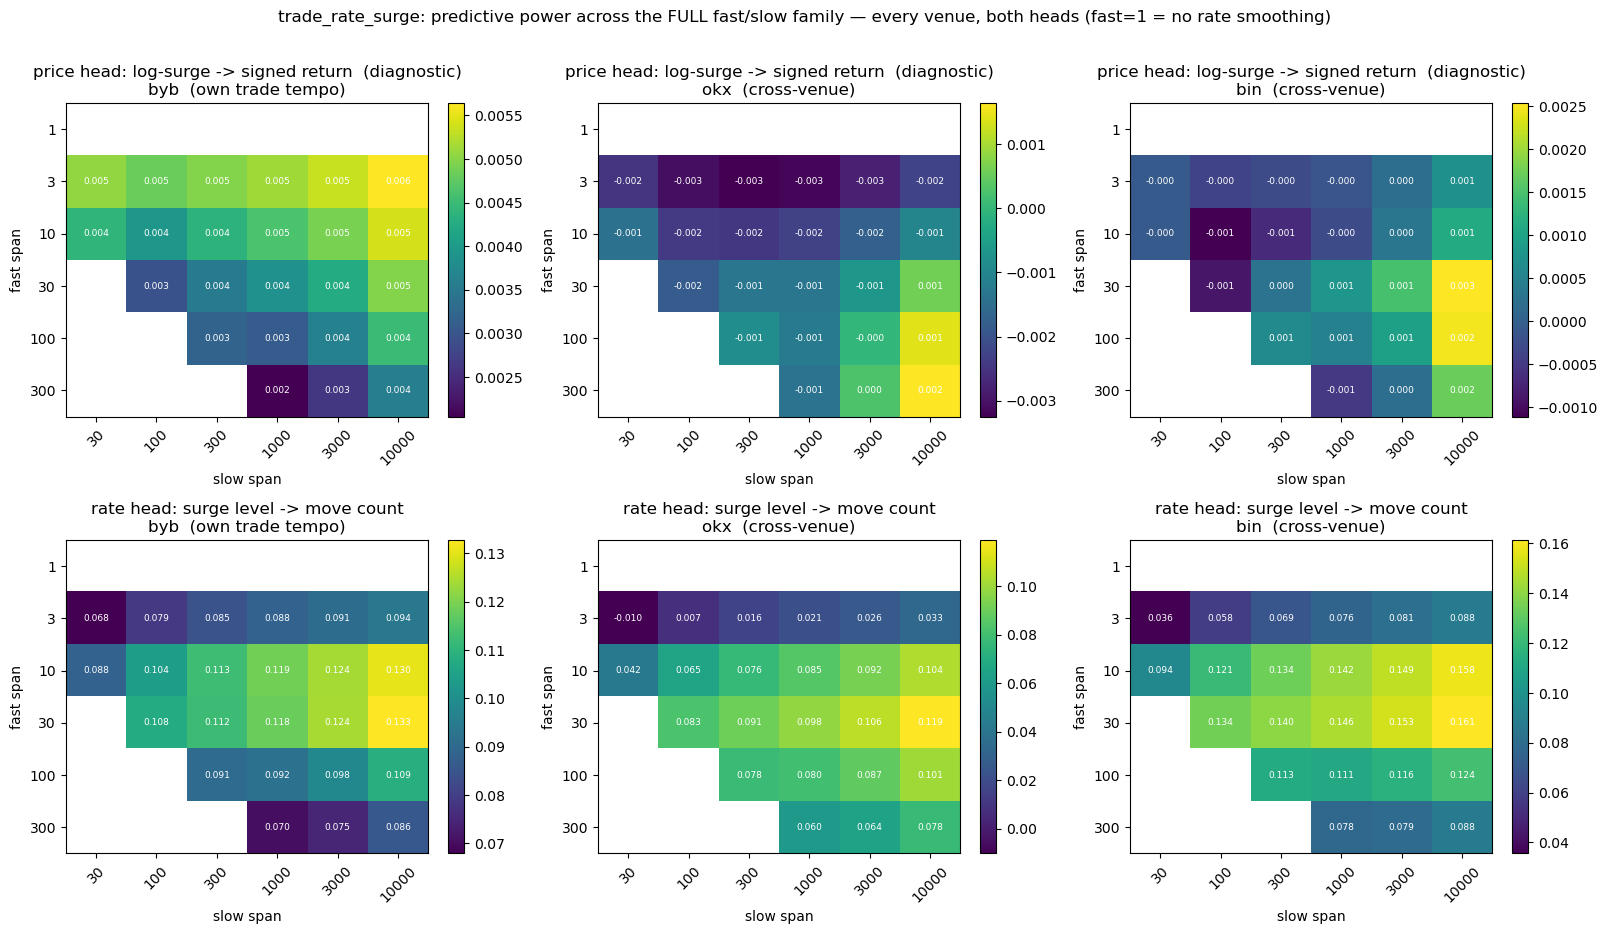

best family member per venue (in-sample pick; re-scored OOS below):
  byb:  price head (fast=3, slow=10000) IC=0.006   |  rate head (fast=30, slow=10000) IC=0.133
  okx:  price head (fast=3, slow=300) IC=-0.003   |  rate head (fast=30, slow=10000) IC=0.119
  bin:  price head (fast=30, slow=10000) IC=0.003   |  rate head (fast=30, slow=10000) IC=0.161


In [5]:
# Sweep the WHOLE family for EVERY venue, BOTH heads. Rate head uses the surge LEVEL (ratio) directly; price head uses log-surge.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # log-surge -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # surge level -> byb's move count (rate_target)
feat_cache = {}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            s = trade_rate_surge(ex, nf, ns); feat_cache[(ex, nf, ns)] = s
            ls = np.log(np.maximum(s, 1e-12))                              # log surge: symmetric around 0, the natural signed form
            price_grid[ex][i, j] = spearmanr(ls, target).statistic        # price head (diagnostic — expected weak)
            rate_grid[ex][i, j]  = spearmanr(s, rate_target).statistic     # rate head — surge level -> move count

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.2), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: log-surge -> signed return  (diagnostic)"),
                                     (rate_grid,  "rate head: surge level -> move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}\n{ex}" + ("  (own trade tempo)" if ex == "byb" else "  (cross-venue)"))
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=6.5)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("trade_rate_surge: predictive power across the FULL fast/slow family — every venue, both heads (fast=1 = no rate smoothing)", y=1.01)
fig.tight_layout(); plt.show()

# In-sample pick of the best family member PER head PER venue (used only to choose a time-scale; re-scored OOS by the gates).
def best_member(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("best family member per venue (in-sample pick; re-scored OOS below):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) IC={price_grid[ex][pi,pj]:.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) IC={rate_grid[ex][ri,rj]:.3f}")

### IC is only half the story — the lifetime of every family member

The heat-maps above rank the family by **headline IC** — but IC at the anchor is not what you can
*capture*. A span with a high IC whose edge is the burst *already underway* dies the instant you add an
observe→act latency; a span with a lower IC whose edge keeps predicting the *next* 100 ms out to tens or
hundreds of ms is the one you can actually trade. So we sweep the **whole family a second time** and, for
**every** (fast, slow) pair, **each head**, **each venue**, measure not just the IC but its **lifetime**:

- **forward IC at δ=0** — the headline (same quantity as the heat-maps, on the diagnostic grid);
- **forward IC at δ=20 ms** — the *realisable* edge after a modest observe→act latency (outcome window
  slid to `[anchor+20ms, anchor+120ms]`);
- **half-life** — the latency δ (ms) at which the forward |IC| first falls below **half** its δ=0 value
  (`>500 ms` if it never does within the swept δ-grid) — the size of your **latency budget**;
- **backward IC** — the feature vs what *already happened* (`[anchor−100ms, anchor]`) — the
  contemporaneous-echo size. A pair whose forward IC at δ=20 ms is ≈0 while its backward IC is large is a
  pure echo, not a prediction, no matter how high its δ=0 IC.

This is run on the **40k-anchor diagnostic sub-grid** (the first 40k anchors past warm-up — ~33 min of
the block) purely for speed: 6×6 spans × 3 venues × 2 heads × 8 latencies is ~3.5k IC evaluations, so the
full 1.7M grid would be needlessly slow; the diagnostic grid moves the same family ranking at a fraction
of the cost.

**The key insight to read off these maps: within one family, IC trades against half-life.** A **short**
fast/slow pair tends to a **higher** δ=0 IC but a **short** half-life (its edge is the freshest tempo
kick, gone in a few ms — a small latency budget); a **long** pair tends to a **lower** δ=0 IC but a
**long** half-life (a slow, persistent tempo regime you can act on tens-to-hundreds of ms late). **Both
are useful** — one for a fast stack, one for a relaxed budget — so per head we surface **more than one**
lookback when the family genuinely offers that short-high-IC vs long-high-half-life trade-off.

In [6]:
# ---- Family-wide SIGNAL LIFETIME: forward IC(δ=0), IC(δ=20ms), HALF-LIFE, backward IC for EVERY (fast,slow), head, venue ----
# Run on the 40k-anchor DIAGNOSTIC sub-grid (first 40k past warm-up) for speed; same family ranking, ~42x cheaper than the full grid.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]            # observe->act latencies swept; half-life encoded as >500 if |IC| never halves
N_DIAG    = 40_000
dx        = slice(0, min(N_DIAG, len(anchor_ts)))         # the diagnostic slice of the grid
adx       = anchor_ts[dx]                                  # diagnostic anchors (start of block, plenty of room ahead for +500ms+100ms)
sig_dx    = sigma_at_anchor[dx]                            # σ_ev on the diagnostic grid (price-head outcome normaliser)
lam_dx    = lam_at_anchor[dx]                              # λ_ev on the diagnostic grid (rate-head outcome normaliser)

def _ic(feat, out):                                       # signed Spearman rank-IC on the finite overlap
    v = np.isfinite(feat) & np.isfinite(out)
    return spearmanr(feat[v], out[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):     return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]   # causal byb mid at-or-before t
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                                # signed byb return over [t0,t1]
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count over [t0,t1]

# Pre-compute the per-δ OUTCOMES once (they don't depend on the feature) — price head ÷ σ_ev, rate head ÷ λ_ev — plus the backward outcome.
ms = 1_000_000
ret_fwd = {d: _ret  (adx + d*ms, adx + d*ms + HORIZON_NS) / sig_dx              for d in DELTAS_MS}   # price-head outcome at each δ (σ-units)
cnt_fwd = {d: _count(adx + d*ms, adx + d*ms + HORIZON_NS) / np.maximum(lam_dx, 1e-9) for d in DELTAS_MS}  # rate-head outcome at each δ
ret_back = _ret  (adx - HORIZON_NS, adx) / sig_dx                                # price-head already-happened return (echo gauge)
cnt_back = _count(adx - HORIZON_NS, adx) / np.maximum(lam_dx, 1e-9)              # rate-head already-happened count (echo gauge)

def half_life(ics):                                       # δ(ms) where |IC| first drops below half its δ=0 value; >500 (->750) if never
    i0 = ics[0]
    if not np.isfinite(i0) or abs(i0) < 1e-9: return np.nan
    for d, ic in zip(DELTAS_MS[1:], ics[1:]):
        if np.isfinite(ic) and abs(ic) < abs(i0) / 2.0: return d
    return 750.0                                          # sentinel: never halves within the swept grid (=">500ms")

HEADS = ["price", "rate"]
# grids[head][stat][ex] : (len(FAST), len(SLOW)) arrays; stat in {ic0, ic20, half, back}
grids = {h: {s: {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES} for s in ("ic0", "ic20", "half", "back")} for h in HEADS}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            rf = trade_rate(ex, adx, nf); rs = trade_rate(ex, adx, ns)
            s  = rf / np.maximum(rs, 1e-12)                                       # surge on the diagnostic grid
            feat = {"price": np.log(np.maximum(s, 1e-12)),                        # price head: log-surge (signed)
                    "rate":  s}                                                   # rate head: surge level
            out_fwd  = {"price": ret_fwd, "rate": cnt_fwd}
            out_back = {"price": ret_back, "rate": cnt_back}
            for h in HEADS:
                ics = [_ic(feat[h], out_fwd[h][d]) for d in DELTAS_MS]
                grids[h]["ic0"][ex][i, j]  = ics[0]
                grids[h]["ic20"][ex][i, j] = ics[DELTAS_MS.index(20)]
                grids[h]["half"][ex][i, j] = half_life(ics)
                grids[h]["back"][ex][i, j] = _ic(feat[h], out_back[h])
print(f"family lifetime sweep on {len(adx):,} diagnostic anchors (δ grid {DELTAS_MS} ms); half-life sentinel 750 = '>500ms (never halves)'")

/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_38939/963789756.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(feat[v], out[v]).statistic if v.sum() > 100 else float("nan")


family lifetime sweep on 40,000 diagnostic anchors (δ grid [0, 5, 10, 20, 50, 100, 200, 500] ms); half-life sentinel 750 = '>500ms (never halves)'


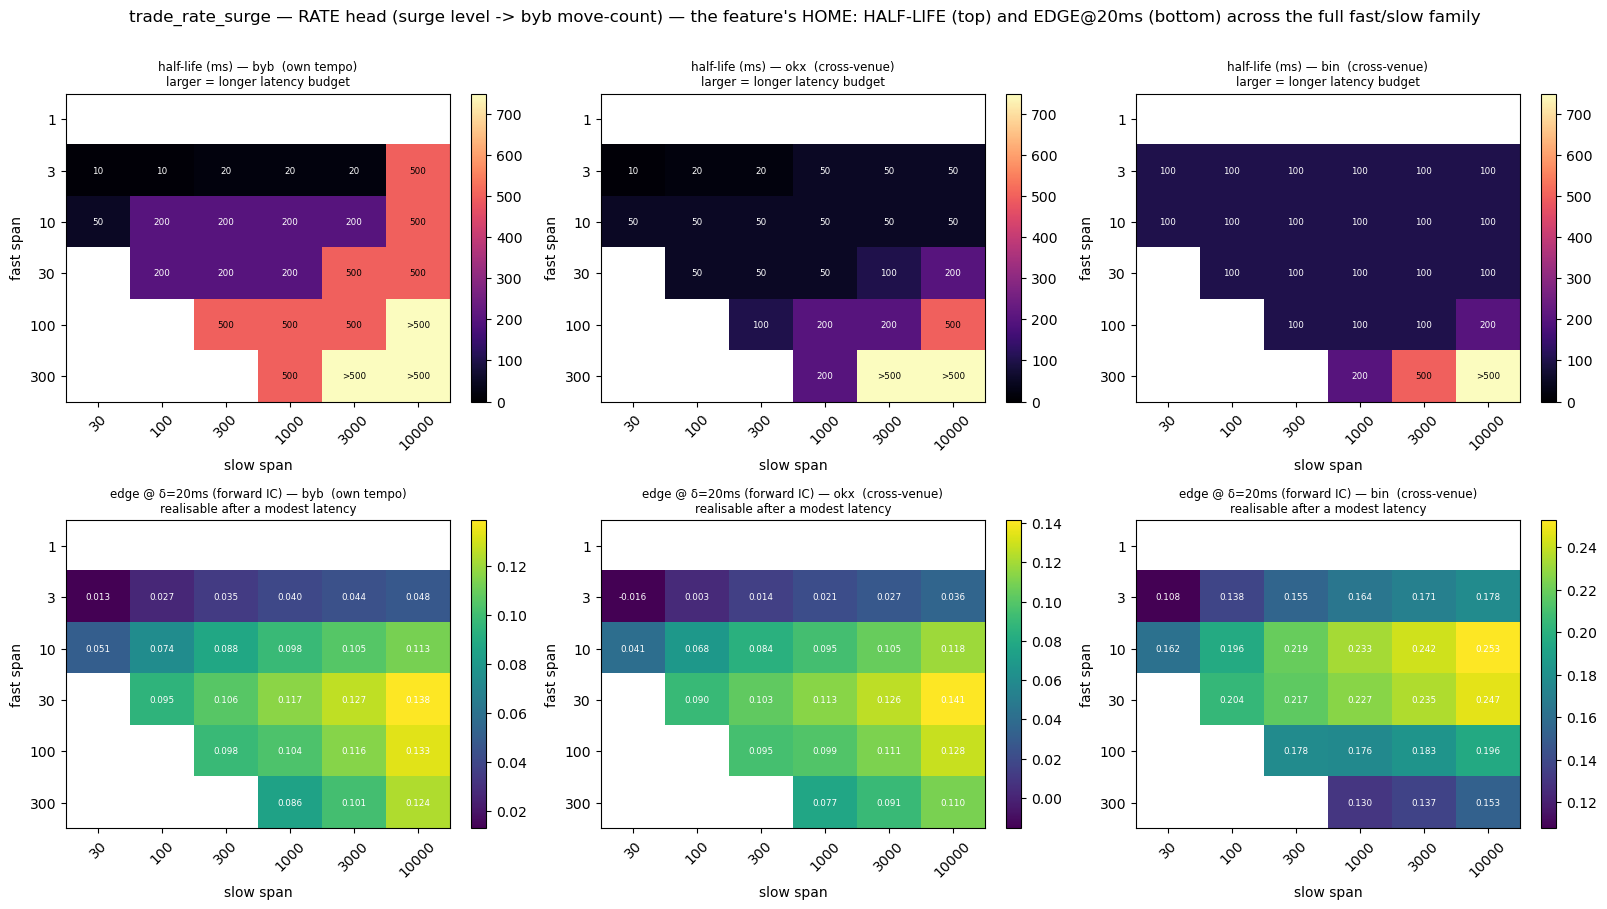

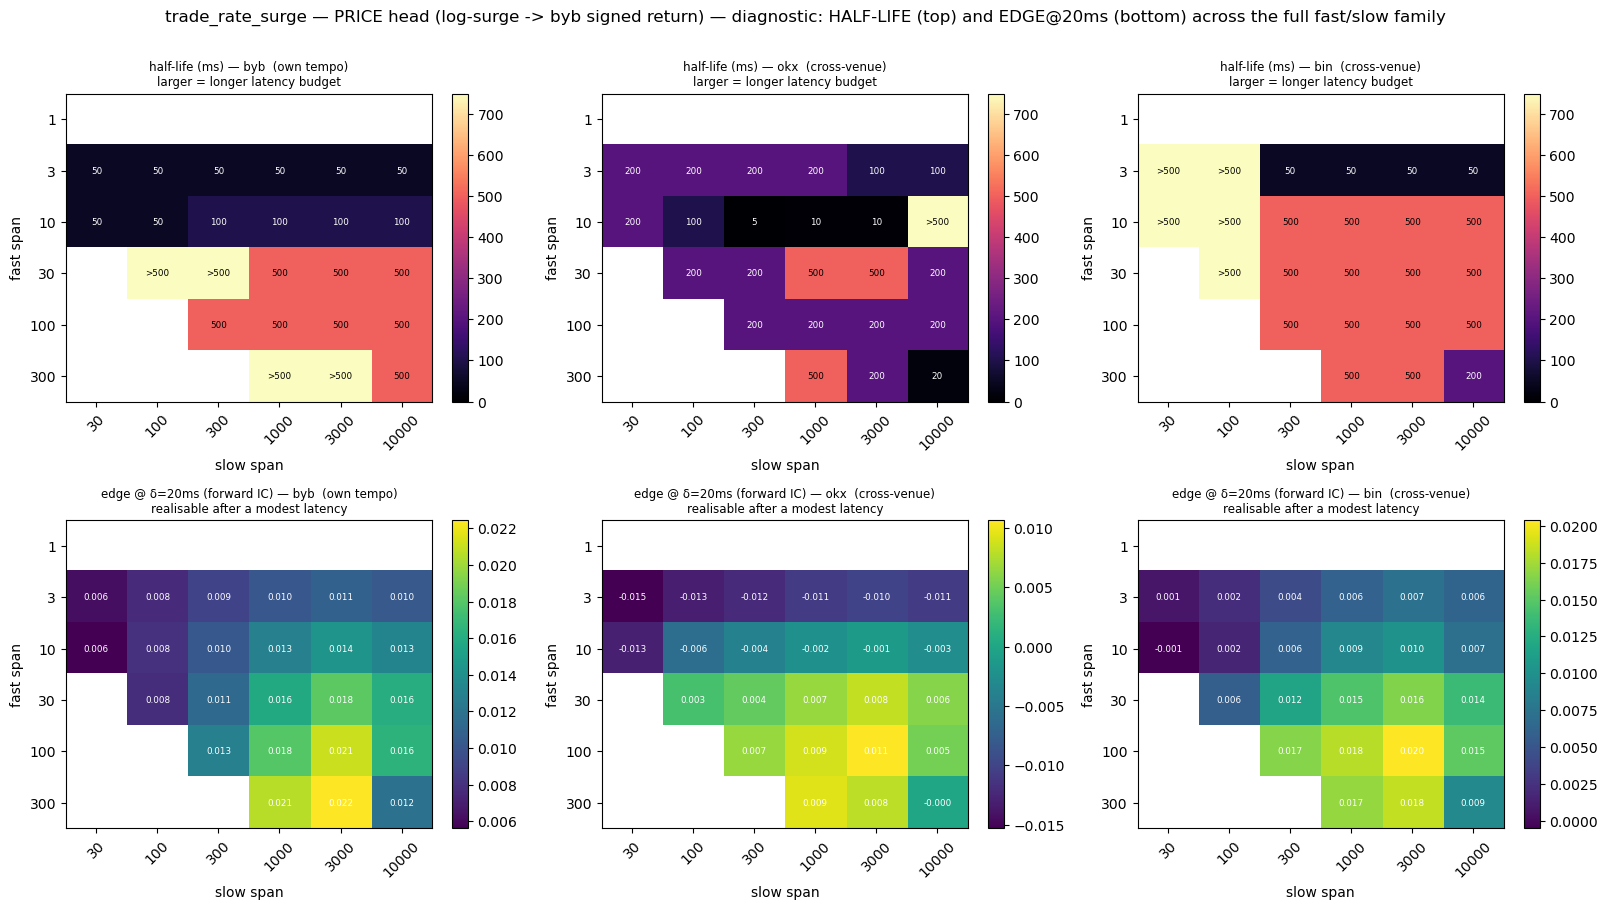

In [7]:
# ---- HALF-LIFE and EDGE@20ms heat-maps across the family, per head/venue — alongside the §6 IC heat-map ----
def _annot(ax, grid, fmt, thr_color):
    for i in range(len(FAST)):
        for j in range(len(SLOW)):
            v = grid[i, j]
            if np.isfinite(v):
                ax.text(j, i, fmt(v), ha="center", va="center", color=thr_color(v), fontsize=6.3)
def _axfmt(ax, title):
    ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
    ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span"); ax.set_title(title, fontsize=8.5)

for head, head_lbl in [("rate", "RATE head (surge level -> byb move-count) — the feature's HOME"),
                       ("price", "PRICE head (log-surge -> byb signed return) — diagnostic")]:
    fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.0), squeeze=False)
    for col, ex in enumerate(EXCHANGES):
        tag = "  (own tempo)" if ex == "byb" else "  (cross-venue)"
        # row 0: HALF-LIFE (ms) — bigger = longer latency budget. 750 shown as ">500".
        h = grids[head]["half"][ex]; ax = axes[0][col]
        im = ax.imshow(h, cmap="magma", aspect="auto", vmin=0, vmax=750)
        _axfmt(ax, f"half-life (ms) — {ex}{tag}\nlarger = longer latency budget")
        _annot(ax, h, lambda v: ">500" if v >= 750 else f"{int(v)}", lambda v: "w" if v < 400 else "k")
        fig.colorbar(im, ax=ax, fraction=0.046)
        # row 1: EDGE @ δ=20ms — realisable IC after a modest latency.
        e = grids[head]["ic20"][ex]; ax = axes[1][col]
        im = ax.imshow(e, cmap="viridis", aspect="auto")
        _axfmt(ax, f"edge @ δ=20ms (forward IC) — {ex}{tag}\nrealisable after a modest latency")
        _annot(ax, e, lambda v: f"{v:.3f}", lambda v: "w")
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"trade_rate_surge — {head_lbl}: HALF-LIFE (top) and EDGE@20ms (bottom) across the full fast/slow family", y=1.005)
    fig.tight_layout(); plt.show()

**Reading the two new maps against the §6 IC map (per head, per venue).** Three numbers now describe
each family member: its **δ=0 IC** (the §6 heat-map — the headline), its **edge@20 ms** (bottom map here
— what survives a modest latency), and its **half-life** (top map — how long the edge lasts). The IC↔
lifetime trade-off shows up as a **gradient**: the short fast/slow corner is brightest on the §6 IC map
but darkest (shortest half-life) on the top map; the long-slow corner is dimmer on IC but bright on
half-life. The cell below turns that into concrete **per-head picks** — a short-high-IC option *and* a
long-high-half-life option whenever the family offers both — and states, per head, whether the head
**carries signal at all** (a meaningful edge@20 ms that is not dominated by the backward echo).

In [8]:
# ---- Pick MORE THAN ONE lookback per head: a short-high-IC option AND a long-high-half-life option (when both exist) ----
def _pairs(head, ex):                                     # all valid (i,j,nf,ns) with finite δ=0 IC for this head/venue
    out = []
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns or not np.isfinite(grids[head]["ic0"][ex][i, j]): continue
            out.append((i, j, nf, ns))
    return out
def _slowness(nf, ns): return ns + nf                     # crude lookback length for ordering short vs long

print("=" * 96)
for head, home in [("rate", "HOME — intensity"), ("price", "diagnostic — direction, expected weak")]:
    print(f"\n### {head.upper()} head  ({home})")
    for ex in EXCHANGES:
        ps = _pairs(head, ex)
        if not ps: print(f"  {ex}: (no finite members)"); continue
        ic0  = {(i, j): grids[head]["ic0"][ex][i, j]  for i, j, _, _ in ps}
        ic20 = {(i, j): grids[head]["ic20"][ex][i, j] for i, j, _, _ in ps}
        half = {(i, j): grids[head]["half"][ex][i, j] for i, j, _, _ in ps}
        back = {(i, j): grids[head]["back"][ex][i, j] for i, j, _, _ in ps}
        # short-high-IC: max |δ=0 IC| (headline punch); long-high-half-life: max half-life, tie-broken by |edge@20ms|.
        hi  = max(ps, key=lambda p: abs(ic0[(p[0], p[1])]))
        lng = max(ps, key=lambda p: (half[(p[0], p[1])], abs(ic20[(p[0], p[1])])))
        def fmt(p):
            i, j, nf, ns = p; k = (i, j)
            hl = ">500" if half[k] >= 750 else f"{int(half[k])}ms"
            return (f"fast={nf:<4} slow={ns:<6} | IC(δ=0)={ic0[k]:+.3f}  IC(20ms)={ic20[k]:+.3f}  "
                    f"half-life={hl:<6}  backward={back[k]:+.3f}")
        tag = "(own)" if ex == "byb" else "(cross)"
        print(f"  {ex} {tag}")
        print(f"     short/high-IC : {fmt(hi)}")
        if (lng[0], lng[1]) != (hi[0], hi[1]):
            print(f"     long/high-HL  : {fmt(lng)}")
        else:
            print(f"     (the high-IC member is also the longest-lived — no separate long option)")
        # carries-signal verdict for this leg: edge@20ms clearly nonzero AND not dominated by the backward echo.
        i, j = hi[0], hi[1]
        e20, bk = ic20[(i, j)], back[(i, j)]
        carries = np.isfinite(e20) and abs(e20) >= 0.02 and abs(e20) >= 0.5 * abs(bk)
        print(f"     carries-signal(best member): edge@20ms={e20:+.3f}  backward={bk:+.3f}  -> {'YES' if carries else 'no/echo'}")
print("\n" + "=" * 96)


### RATE head  (HOME — intensity)
  byb (own)
     short/high-IC : fast=30   slow=10000  | IC(δ=0)=+0.170  IC(20ms)=+0.138  half-life=500ms   backward=+0.477
     long/high-HL  : fast=100  slow=10000  | IC(δ=0)=+0.149  IC(20ms)=+0.133  half-life=>500    backward=+0.330
     carries-signal(best member): edge@20ms=+0.138  backward=+0.477  -> no/echo
  okx (cross)
     short/high-IC : fast=30   slow=10000  | IC(δ=0)=+0.174  IC(20ms)=+0.141  half-life=200ms   backward=+0.305
     long/high-HL  : fast=300  slow=10000  | IC(δ=0)=+0.118  IC(20ms)=+0.110  half-life=>500    backward=+0.162
     carries-signal(best member): edge@20ms=+0.141  backward=+0.305  -> no/echo
  bin (cross)
     short/high-IC : fast=30   slow=10000  | IC(δ=0)=+0.279  IC(20ms)=+0.247  half-life=100ms   backward=+0.304
     long/high-HL  : fast=300  slow=10000  | IC(δ=0)=+0.163  IC(20ms)=+0.153  half-life=>500    backward=+0.188
     carries-signal(best member): edge@20ms=+0.247  backward=+0.304  -> YES

### PRICE head  

**The lifetime read, honestly, per head.** The print above is the family's IC-vs-lifetime trade-off made
concrete. For the **rate head** (the home): where the short/high-IC and long/high-HL rows *differ*, the
family genuinely offers two usable lookbacks — a sharp pair (high δ=0 IC, short half-life: needs a fast
stack) and a slow pair (lower IC, long half-life: a relaxed latency budget) — and we keep **both**, per
venue, rather than collapsing to one N. The **carries-signal** line is the honest gate: a head carries
signal on a leg only if its **edge@20 ms** is clearly nonzero (≥ ~0.02) **and** not dominated by the
**backward** echo (forward ≥ ~half the backward) — a high δ=0 IC that evaporates by 20 ms or merely
re-reports the already-fired burst is *not* a tradable edge. The **price head** is expected to fail this
on every venue (intensity ≠ direction); we report it straight either way. These picks feed the §6 gates
below and the §10 verdict — the heat-maps now show **IC and lifetime together**, not IC at one chosen N.

**Now the gates** (from §5), on the per-venue rate-head picks. Every predictive number is the
**walk-forward** mean (causal, purged). The gates: *Marginal value* — does each leg add over the
controls (and do they add *jointly*)? *No leak* — does any gain survive adding the vol/rate *levels*?
*Normaliser* — is the feature's scale steady across vol buckets (a ratio, so trivial)? *Regime-stable*
— is the marginal gain positive within calm/mid/wild vol?

We run the gates **against the rate head** (the feature's home). The headline read is the **marginal
over the move-rate controls, per leg**: byb's trade-rate surge over `rate_momentum` is the honest test
of whether **trade** tempo carries intensity beyond **move** tempo (the control circularity is partial
here, unlike `mid_rate_surge`); the **okx/bin** legs add the cross-venue test. We report each straight.

In [9]:
surge = {ex: feat_cache[(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]])] for ex in EXCHANGES}  # rate-head pick per venue

# Marginal value on the RATE head, PER LEG (the honest per-exchange test) + JOINT (all venues together).
m_each      = {ex: round(wf_ic(base + [surge[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in EXCHANGES}
m_joint     = round(wf_ic(base + list(surge.values()), rate_target) - wf_ic(base, rate_target), 3)
m_cross_only = round(wf_ic(base + [surge["okx"], surge["bin"]], rate_target) - wf_ic(base, rate_target), 3)
m_joint_leak = round(wf_ic(base + levels + list(surge.values()), rate_target) - wf_ic(base + levels, rate_target), 3)

# normaliser: feature scale across volatility buckets (already a ratio -> should be steady). Use the byb leg as representative.
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(surge["byb"][vol_decile == d]) for d in range(10)]
# regime companion: marginal RATE-head IC within each vol regime, JOINT over all legs
full_r = wf_ic_by_regime(base + list(surge.values()), rate_target, vol_regime)
base_r = wf_ic_by_regime(base, rate_target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}

gate_rows = [dict(gate="marginal value (RATE head)", detail=f"{ex} leg alone, added over rate+vol MOMENTA"
                  + ("  [byb own trade tempo vs MOVE-rate control]" if ex == "byb" else "  [cross-venue trade tempo]"), value=m_each[ex]) for ex in EXCHANGES]
gate_rows += [
    dict(gate="marginal value (RATE head)", detail="all three venues JOINTLY, added over the controls", value=m_joint),
    dict(gate="marginal value (RATE head)", detail="okx+bin CROSS-VENUE legs only (no byb leg) over controls", value=m_cross_only),
    dict(gate="no leak (RATE head)", detail="joint gain still there after adding the vol/rate LEVELS?", value=m_joint_leak),
    dict(gate="normaliser", detail="byb-leg scale across vol buckets (max/min, want < ~3)", value=round(max(band) / min(band), 2)),
]
gate_rows += [dict(gate="regime-stable (RATE)", detail=f"joint marginal RATE IC within {nm}-vol (companion)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
# also report the PRICE-head joint marginal, for completeness (this feature is primarily rate)
price_surge = {ex: feat_cache[(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]])] for ex in EXCHANGES}
price_joint = round(wf_ic(base + [np.log(np.maximum(v, 1e-12)) for v in price_surge.values()], target) - wf_ic(base, target), 3)
gate_rows += [dict(gate="marginal value (PRICE head)", detail="all venues' log-surge jointly, added over the controls", value=price_joint)]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""marginal value (RATE head)""","""byb leg alone, added over rate…",0.052
"""marginal value (RATE head)""","""okx leg alone, added over rate…",0.051
"""marginal value (RATE head)""","""bin leg alone, added over rate…",0.084
"""marginal value (RATE head)""","""all three venues JOINTLY, adde…",0.09
"""marginal value (RATE head)""","""okx+bin CROSS-VENUE legs only …",0.087
…,…,…
"""normaliser""","""byb-leg scale across vol bucke…",1.41
"""regime-stable (RATE)""","""joint marginal RATE IC within …",0.085
"""regime-stable (RATE)""","""joint marginal RATE IC within …",0.093


**Conclusion — read per leg, against the trade-rate-vs-move-rate distinction.** The headline numbers
are the **marginal values over the rate/vol momenta** on the **rate head**, reported straight. The key
contrast with `mid_rate_surge`: there the byb leg was a near-twin of `rate_momentum` and added ~0; here
the control is the **move** rate while the feature is the **trade** rate, so even the **byb** leg's
marginal is an honest test of whether trade tempo carries intensity the move-rate regime misses. **Read
the table above for the realised numbers** — if byb's trade-rate surge adds clear marginal value over
`rate_momentum`, that is the headline finding (trade rate ≠ move rate, and the difference is
predictive); if it collapses to ≈0, byb's trade tempo carries nothing its move rate didn't. The **okx**
and **bin** legs (and the **okx+bin only** row) are the cross-venue test — does another venue's trade
tempo lead byb's move-count? The **joint** row separates "does the family help at all" from the
per-leg picture; the **no-leak** row checks the gain survives the level controls; the normaliser passes
trivially (a dimensionless ratio); the regime rows check the gain isn't a one-regime artefact. The
**price-head** marginal is reported last — we expect it small (trade tempo is intensity, not direction).
Whatever the realised values, we quote the **§6 marginal**, never a raw IC.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the burst *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that activity
has already happened. But a **short**-lived edge is **not** useless — it just sets a **latency budget**:
any system fast enough to act inside it wins, faster is always better, and any genuine forward prediction
is a win. So we do **not** gate on this — we **measure how long the signal lasts**, per venue.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's outcome over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to noise is the signal's **lifetime**. The **backward IC** — against what *already happened*,
`[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A feature whose forward IC dies at δ>0 while
the backward IC stays high is re-reporting the past, not predicting it; that is the *only* genuinely
useless case, and it is measured here, never assumed.

`trade_rate_surge` is an **intensity** feature, so its natural head is the **rate head**: the surge
**level** against byb's forward **move-count** over the slid window (a `_count` outcome). We also carry
the **price-head** diagnostic (log-surge → byb's signed return), expected weak. We compute **both curves
per venue** (byb own tempo; okx/bin cross-venue) — the **cross-venue legs' δ=0-vs-δ=20ms gap is exactly
how you tell a feed-resolution / contemporaneous-echo artefact from a real cross-venue lead**: a real
trade-tempo lead survives a 20 ms slide, a same-instant echo does not.

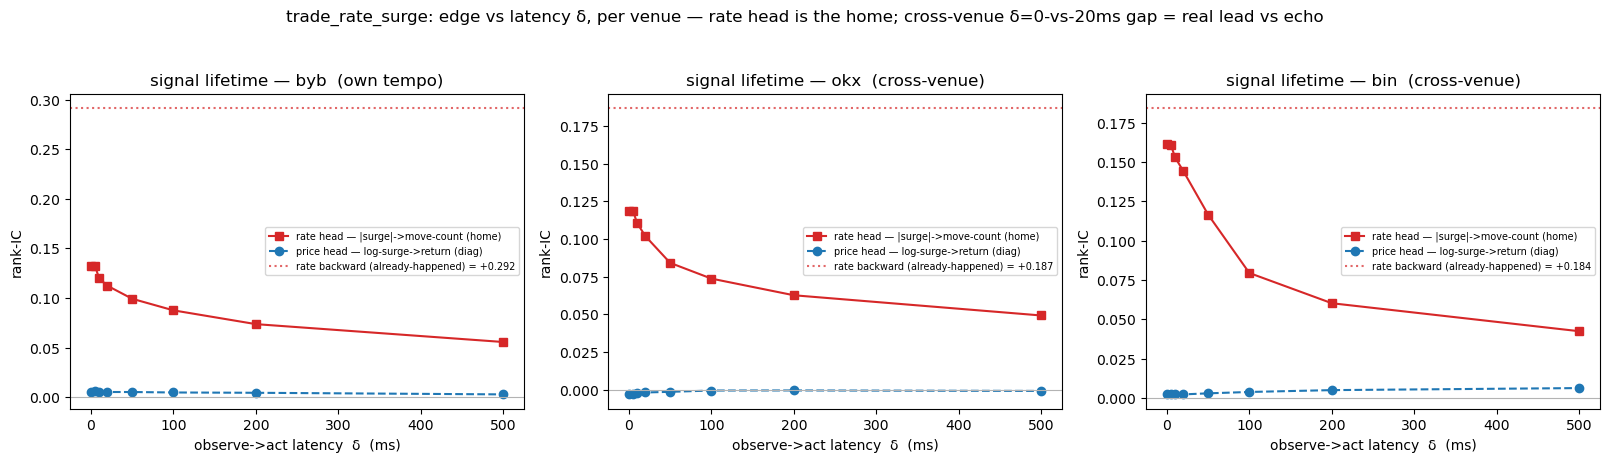

RATE head (surge level -> byb forward move-count) — the feature's home:
  byb forward IC by δ(ms): 0:+0.132 5:+0.132 10:+0.120 20:+0.112 50:+0.099 100:+0.087 200:+0.074 500:+0.056
     edge@20ms +0.112  (δ=0 +0.132);  half-life δ≈500 ms;  backward(already-happened) +0.292
  okx forward IC by δ(ms): 0:+0.119 5:+0.119 10:+0.111 20:+0.102 50:+0.084 100:+0.074 200:+0.063 500:+0.049
     edge@20ms +0.102  (δ=0 +0.119);  half-life δ≈500 ms;  backward(already-happened) +0.187
  bin forward IC by δ(ms): 0:+0.161 5:+0.161 10:+0.153 20:+0.144 50:+0.117 100:+0.079 200:+0.060 500:+0.042
     edge@20ms +0.144  (δ=0 +0.161);  half-life δ≈100 ms;  backward(already-happened) +0.184
PRICE head (log-surge -> byb signed return) — diagnostic, expected weak:
  byb forward IC by δ(ms): 0:+0.006 5:+0.006 10:+0.005 20:+0.005 50:+0.005 100:+0.005 200:+0.004 500:+0.003   backward +0.008
  okx forward IC by δ(ms): 0:-0.003 5:-0.003 10:-0.002 20:-0.002 50:-0.002 100:-0.001 200:-0.001 500:-0.001   backward -0.008


In [10]:
# Signal lifetime: forward IC vs observe->act latency δ (outcome window slides to [t+δ, t+δ+100ms]), + backward IC, PER VENUE.
# Rate head (this feature's home): surge LEVEL -> byb forward MOVE-COUNT. Price head (diagnostic): log-surge -> byb signed return.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, out):
    v = np.isfinite(feat) & np.isfinite(out)
    return spearmanr(feat[v], out[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal forward-fill)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                       # signed byb return over [t0,t1]
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count over [t0,t1]

# per-venue heads: rate head uses the rate-head pick (surge level); price head uses the price-head pick (log-surge).
rate_lvl = {ex: surge[ex] for ex in EXCHANGES}                                                     # surge level -> move count (rate head)
price_ls = {ex: np.log(np.maximum(price_surge[ex], 1e-12)) for ex in EXCHANGES}                    # log-surge   -> signed return (price head)

cnt_ic  = {ex: [_ic(rate_lvl[ex],  _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS] for ex in EXCHANGES}
fwd_ic  = {ex: [_ic(price_ls[ex],  _ret  (anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS] for ex in EXCHANGES}
back_cnt = {ex: _ic(rate_lvl[ex], _count(anchor_ts - HORIZON_NS, anchor_ts)) for ex in EXCHANGES}  # already-happened move-count (rate-head echo)
back_ret = {ex: _ic(price_ls[ex], _ret  (anchor_ts - HORIZON_NS, anchor_ts)) for ex in EXCHANGES}  # already-happened signed return (price-head echo)

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, cnt_ic[ex], "s-", color="C3", label="rate head — |surge|->move-count (home)")
    ax.plot(DELTAS_MS, fwd_ic[ex], "o--", color="C0", label="price head — log-surge->return (diag)")
    ax.axhline(back_cnt[ex], color="C3", ls=":", alpha=0.7, label=f"rate backward (already-happened) = {back_cnt[ex]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    ax.set_title(f"signal lifetime — {ex}" + ("  (own tempo)" if ex == "byb" else "  (cross-venue)"))
    ax.legend(fontsize=7)
fig.suptitle("trade_rate_surge: edge vs latency δ, per venue — rate head is the home; cross-venue δ=0-vs-20ms gap = real lead vs echo", y=1.04)
fig.tight_layout(); plt.show()

# Prints: the rate-head decay curve per venue, the δ=20ms realisable edge, the half-life, and the backward echo.
print("RATE head (surge level -> byb forward move-count) — the feature's home:")
for ex in EXCHANGES:
    print(f"  {ex} forward IC by δ(ms): " + " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, cnt_ic[ex])))
    half = next((d for d, ic in zip(DELTAS_MS, cnt_ic[ex]) if np.isfinite(ic) and abs(ic) < abs(cnt_ic[ex][0]) / 2), None)
    print(f"     edge@20ms {cnt_ic[ex][3]:+.3f}  (δ=0 {cnt_ic[ex][0]:+.3f});  half-life δ≈{half} ms;  backward(already-happened) {back_cnt[ex]:+.3f}")
print("PRICE head (log-surge -> byb signed return) — diagnostic, expected weak:")
for ex in EXCHANGES:
    print(f"  {ex} forward IC by δ(ms): " + " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, fwd_ic[ex]))
          + f"   backward {back_ret[ex]:+.3f}")

**Read it as a latency budget, not a pass/fail.** If a venue's rate-head forward IC stays useful out to
tens or hundreds of ms you have room; if it lives only a handful of ms the signal is real but demands a
fast stack. The **backward** (already-happened move-count) IC sizes how much of the apparent edge is the
burst that already fired by the anchor: a forward curve that stays well above 0 at δ>0 is genuine lead;
a forward curve that collapses to ≈0 at δ>0 while the backward IC stays large is the one true non-signal —
a contemporaneous echo of activity already underway. Carry this curve for **every venue** — the verdict
is *"venue X's trade surge predicts byb's move-count ~Y ms ahead, needs latency < Y,"* never *"drop
because it's fast."* For the cross-venue legs (okx/bin) the δ=0-vs-δ=20ms step is the cleanest read on
whether the lead is a real beat or a feed-resolution coincidence.

### GATE 1 — the echo-netted (partial) forward IC, per head per leg

A forward IC at δ=0 can be inflated by the **contemporaneous echo**: the burst already underway at the
anchor leaks into both the feature *and* the forward outcome (adjacent 100 ms windows overlap, and a
trade surge that just fired is mechanically correlated with the move-burst it accompanies). The byb leg
is **own-echo-heavy** — its backward IC rivals its forward IC — so its raw δ=0 IC over-credits that echo.
We net it out with a **partial Spearman**: the feature's rank-IC with the **forward** outcome,
**controlling for the trailing** (already-happened) outcome over `[anchor−100 ms, anchor]`:

`ic_net = (r_fy − r_ft·r_ty) / √((1−r_ft²)(1−r_ty²))`,  f = feature@anchor, y = forward, t = trailing.

We apply it **per head with the matching outcome** — **rate head → forward vs trailing move-COUNT**
(the feature's home), **price head → forward vs trailing signed RETURN** (the diagnostic). If a big raw
IC collapses once the trailing burst is partialled out, the leg was re-reporting the past; if it
survives, it is genuine forward prediction. The §10 verdict quotes the **netted** number for any
echo-heavy leg (backward IC ≥ forward).

In [11]:
# GATE 1: ECHO-NETTED (partial) forward IC — the part of each leg's edge NOT attributable to the burst ALREADY underway.
# Partial Spearman of feature@anchor with the FORWARD outcome, CONTROLLING for the TRAILING [anchor-100ms, anchor] outcome.
# Applied PER HEAD with its own outcome: RATE head -> forward vs trailing MOVE-COUNT (home); PRICE head -> forward vs trailing signed RETURN.
def _partial_ic(f, y, ctrl):                                                # rank-partial corr of f,y controlling for ctrl
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(ctrl)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], ctrl[v]).statistic; rty = spearmanr(ctrl[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

# the two outcomes, forward (δ=0) and trailing (already-happened), per head
fwd0_count  = _count(anchor_ts, anchor_ts + HORIZON_NS)                     # rate head: δ=0 forward move-count
trail_count = _count(anchor_ts - HORIZON_NS, anchor_ts)                     # rate head: trailing move-burst (the echo)
fwd0_ret    = _ret(anchor_ts, anchor_ts + HORIZON_NS)                       # price head: δ=0 forward signed return
trail_ret   = _ret(anchor_ts - HORIZON_NS, anchor_ts)                       # price head: trailing signed return (the echo)

echo_net_rate  = {ex: _partial_ic(rate_lvl[ex], fwd0_count, trail_count) for ex in EXCHANGES}   # rate head (surge level -> count)
echo_net_price = {ex: _partial_ic(price_ls[ex], fwd0_ret,   trail_ret)   for ex in EXCHANGES}   # price head (log-surge -> return)

print("GATE 1 — echo-netted (partial) forward IC, per leg.  raw δ=0 IC -> echo-netted IC (shortfall = echo):")
print("  RATE head (surge level -> byb forward move-count; controls for the trailing move-count) — the HOME:")
for ex in EXCHANGES:
    raw, net, bk = cnt_ic[ex][0], echo_net_rate[ex], back_cnt[ex]
    tag = "own" if ex == "byb" else "cross-venue"
    echoy = "  <- ECHO-HEAVY (backward >= forward): quote the NETTED number" if (np.isfinite(bk) and abs(bk) >= abs(raw)) else ""
    print(f"    {ex:4} ({tag:11}): raw δ=0 {raw:+.3f} -> echo-netted {net:+.3f}  (backward {bk:+.3f}){echoy}")
print("  PRICE head (log-surge -> byb forward signed return; controls for the trailing return) — diagnostic:")
for ex in EXCHANGES:
    raw, net, bk = fwd_ic[ex][0], echo_net_price[ex], back_ret[ex]
    print(f"    {ex:4}: raw δ=0 {raw:+.3f} -> echo-netted {net:+.3f}  (backward {bk:+.3f})")

GATE 1 — echo-netted (partial) forward IC, per leg.  raw δ=0 IC -> echo-netted IC (shortfall = echo):
  RATE head (surge level -> byb forward move-count; controls for the trailing move-count) — the HOME:
    byb  (own        ): raw δ=0 +0.132 -> echo-netted +0.055  (backward +0.292)  <- ECHO-HEAVY (backward >= forward): quote the NETTED number
    okx  (cross-venue): raw δ=0 +0.119 -> echo-netted +0.071  (backward +0.187)  <- ECHO-HEAVY (backward >= forward): quote the NETTED number
    bin  (cross-venue): raw δ=0 +0.161 -> echo-netted +0.116  (backward +0.184)  <- ECHO-HEAVY (backward >= forward): quote the NETTED number
  PRICE head (log-surge -> byb forward signed return; controls for the trailing return) — diagnostic:
    byb : raw δ=0 +0.006 -> echo-netted +0.004  (backward +0.008)
    okx : raw δ=0 -0.003 -> echo-netted -0.001  (backward -0.008)
    bin : raw δ=0 +0.003 -> echo-netted +0.002  (backward +0.002)


**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The print above
is the honest "is this real forward prediction?" number per leg, per head: the feature's rank-IC with the
forward outcome *with the trailing outcome partialled out*. For the **rate head** (the home) the byb leg
is the one to watch — it is own-echo-heavy (a byb trade surge mechanically co-occurs with byb's
move-burst), so if its raw δ=0 IC shrinks sharply once the trailing move-count is netted out, that
shortfall *was* echo and the netted number is the one to quote. A leg whose netted IC stays close to its
raw IC is genuinely forecasting the *next* window, not re-reporting the current one. The **price head** is
the diagnostic and expected near 0 either way (intensity ≠ direction). The §10 verdict cites the
**echo-netted** IC for any echo-heavy leg, never the raw δ=0 IC.

### GATE 2 — the feed-resolution control on the cross-venue (okx/bin) legs

A cross-venue "lead" can be an **artefact of feed resolution**, not economics. okx and bin print and
update on their own cadence; if a foreign venue's trade-events are simply observed at **finer
time-resolution** than byb refreshes its own book, its trade-rate surge can look like it "leads" byb
purely because it is *fresher*, not because it economically *precedes* byb's moves. The control follows
the template's recipe: **re-measure each cross-venue leg's rate-head IC with the foreign feed matched to
byb's update cadence** — sample the foreign surge only at byb's update times by snapping every anchor's
foreign read back to byb's most recent book-update time at-or-before it, then re-score against the forward
move-count. A **real** lead survives the cadence match (byb still hasn't reacted by its own next update); a
**feed-resolution artefact** collapses toward zero. The tell: if the *stalest* venue shows the *largest*
raw IC, suspect resolution. We report the matched IC beside the raw IC for okx and bin (byb shown for
reference — coarsening byb to its own cadence is a near-no-op).

In [12]:
# GATE 2: FEED-RESOLUTION CONTROL (cross-venue okx/bin) — re-read each foreign surge at BYB's update cadence and re-score.
# byb's book-update times = its raw front_levels rx (its own feed's resolution). Snapping each anchor's foreign-surge read
# to byb's most-recent update at-or-before it makes the foreign feed no fresher than byb's own — a real economic lead
# survives (byb hasn't moved by its next own update), a finer-resolution artefact collapses toward zero.
byb_upd    = byb_rx0                                                        # byb's RAW book-update receive-times (its feed cadence)
byb_gap_ms = float(np.median(np.diff(byb_upd))) / 1e6
byb_anchor = byb_upd[np.clip(np.searchsorted(byb_upd, anchor_ts, "right") - 1, 0, len(byb_upd) - 1)]   # byb's last update at-or-before each anchor
match_idx  = np.searchsorted(anchor_ts, byb_anchor, "right") - 1            # re-read the SAME §3 surge AS OF that byb-update time (coarsened)
print(f"GATE 2 — feed-resolution control.  byb median inter-update gap: {byb_gap_ms:.1f} ms (the cadence the foreign feed is matched to)")
print("  cross-venue rate-head IC (surge level -> byb forward move-count):  raw IC -> byb-cadence-matched IC:")
for ex in EXCHANGES:
    raw_surge     = surge[ex]                                              # read at the true anchor (full resolution)
    matched_surge = surge[ex][np.clip(match_idx, 0, len(surge[ex]) - 1)]   # read AS OF byb's last update (cadence-matched)
    ic_raw   = _ic(raw_surge, fwd0_count); ic_match = _ic(matched_surge, fwd0_count)
    retained = (ic_match / ic_raw * 100) if ic_raw else float("nan")
    if ex == "byb":
        verdict = "  (own leg — reference; coarsening byb to its own cadence is a near-no-op)"
    else:
        verdict = "  -> LEAD SURVIVES" if abs(ic_match) > 0.5 * abs(ic_raw) else "  -> COLLAPSES (feed-resolution artefact)"
    tag = "own" if ex == "byb" else "cross-venue"
    print(f"    {ex:4} ({tag:11}): raw IC {ic_raw:+.3f}   byb-cadence-matched IC {ic_match:+.3f}   retained {retained:5.0f}%{verdict}")

GATE 2 — feed-resolution control.  byb median inter-update gap: 10.2 ms (the cadence the foreign feed is matched to)
  cross-venue rate-head IC (surge level -> byb forward move-count):  raw IC -> byb-cadence-matched IC:


    byb  (own        ): raw IC +0.132   byb-cadence-matched IC +0.095   retained    72%  (own leg — reference; coarsening byb to its own cadence is a near-no-op)


    okx  (cross-venue): raw IC +0.119   byb-cadence-matched IC +0.083   retained    70%  -> LEAD SURVIVES


    bin  (cross-venue): raw IC +0.161   byb-cadence-matched IC +0.109   retained    68%  -> LEAD SURVIVES


**Reading the feed-resolution control.** Compare each cross-venue leg's **raw** rate-head IC to its
**byb-cadence-matched** IC. If the matched IC stays close to the raw one, the okx/bin trade-tempo lead is
**economic** — it still predicts byb's next move-count when the foreign feed is sampled no finer than
byb's own updates. If it **collapses** toward zero, the apparent lead was a **feed-resolution artefact**
(the foreign book merely sampled finer than byb's), and that leg should not be sold as a cross-venue lead;
the tell is the stalest venue carrying the largest raw IC. The byb (own) leg is shown for reference only —
coarsening byb to its own cadence changes almost nothing. The §10 verdict quotes the **cadence-matched**
cross-venue numbers, never the raw ones.

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and look
at the real distributions the heads care about, **per venue** (byb's own tempo vs the cross-venue legs):
- **rate head (its home):** how the number of upcoming byb moves grows as each venue's trade-surge ratio grows;
- **price head (diagnostic):** byb's next return for low / middle / high *signed* (log-)surge — expected
  roughly flat, since intensity isn't direction.

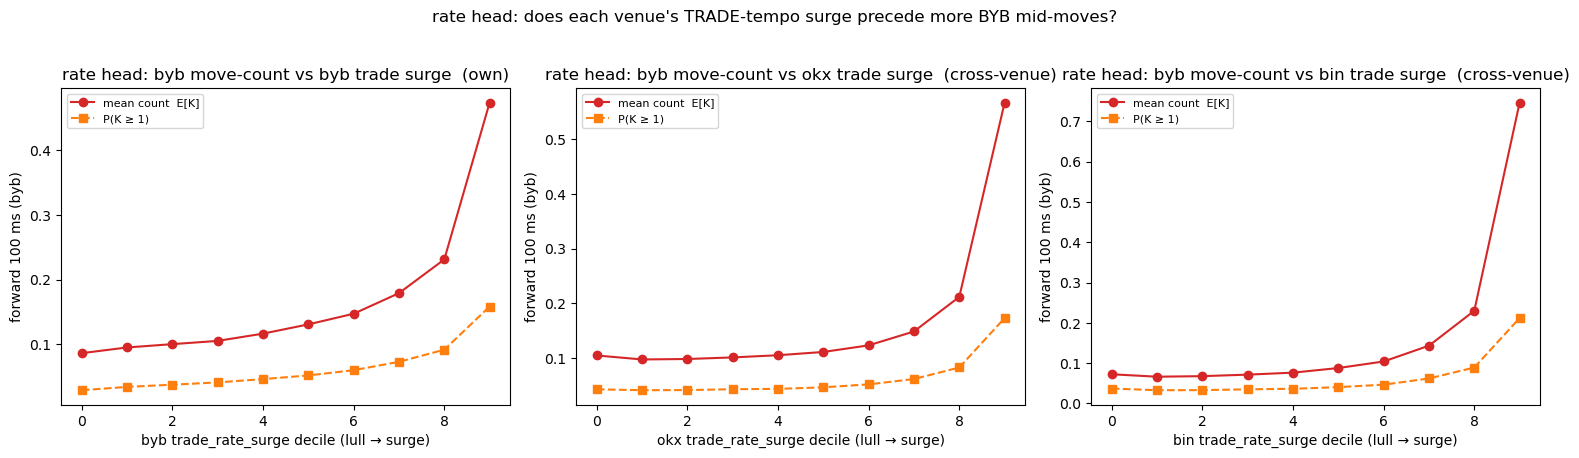

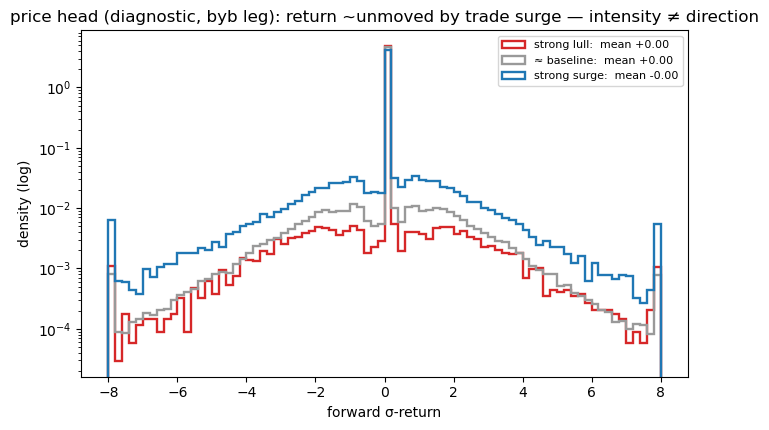

In [13]:
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    s = surge[ex]; ax = axes[0][col]
    dec = np.digitize(s, np.nanpercentile(s[np.isfinite(s)], np.arange(10, 100, 10)))
    ax.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
    ax.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
    ax.set_xlabel(f"{ex} trade_rate_surge decile (lull → surge)"); ax.set_ylabel("forward 100 ms (byb)")
    ax.set_title(f"rate head: byb move-count vs {ex} trade surge" + ("  (own)" if ex == "byb" else "  (cross-venue)")); ax.legend(fontsize=8)
fig.suptitle("rate head: does each venue's TRADE-tempo surge precede more BYB mid-moves?", y=1.03)
fig.tight_layout(); plt.show()

# price head (diagnostic): forward σ-return across signed log-surge buckets — expected ~flat — shown for the byb leg
s = surge["byb"]; ls = np.log(np.maximum(s, 1e-12))
fig, axB = plt.subplots(1, 1, figsize=(7, 4.4))
lo, hi = np.nanpercentile(ls, [10, 90])
groups = [("strong lull", ls <= lo, "C3"), ("≈ baseline", (ls > lo) & (ls < hi), "0.6"), ("strong surge", ls >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic, byb leg): return ~unmoved by trade surge — intensity ≠ direction"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (top row):** read the per-venue panels — for the **byb** leg the mean
move-count `E[K]` and `P(K ≥ 1)` should climb from lull to surge deciles (the §1 intensity story: a
trade surge precedes more byb moves); the **okx/bin** panels show whether *another* venue's trade surge
also tracks byb's upcoming move-count (a cross-venue lead) or is flat. **Price head (bottom):** the
forward-return distribution barely shifts across lull / baseline / surge groups (means ≈ 0) — a surge
says *how many*, not *which way*, confirming this is an intensity feature. The open question §6/§9
answers is whether any leg's signal is **new** over `rate_momentum` — and here, because the control is
the *move* rate and this is the *trade* rate, even byb's own leg has a genuine shot.

## 8. Input shaping for the network

This reshapes the feature for the network's input — roughly centred, unit-scale, no wild outliers — a
*different* step from §2 (there is no regime division here; the feature is already a ratio). A surge
*ratio* is positive and right-skewed, so its **log** is the natural signed, centred form. We feed **every
venue's** log-surge (none privileged). Plot the byb leg (left) and compare candidates by how close to a
clean bell curve they make it (right — points on the diagonal are perfectly normal). Pick the lightest
transform that clears the bar; the same transform applies per venue.

raw ratio: skew=+34.27  excess_kurt=3048.7
log surge: skew=-0.72  excess_kurt=20.8  (0 = normal)
  raw ratio (z)          excess_kurt=3048.7   max|·|=207.6
  log surge (z)          excess_kurt=  20.8   max|·|=36.0
  log robust + clip ±4   excess_kurt=   1.0   max|·|=4.0
  rank-Gaussian(log)     excess_kurt=  -0.0   max|·|=5.0


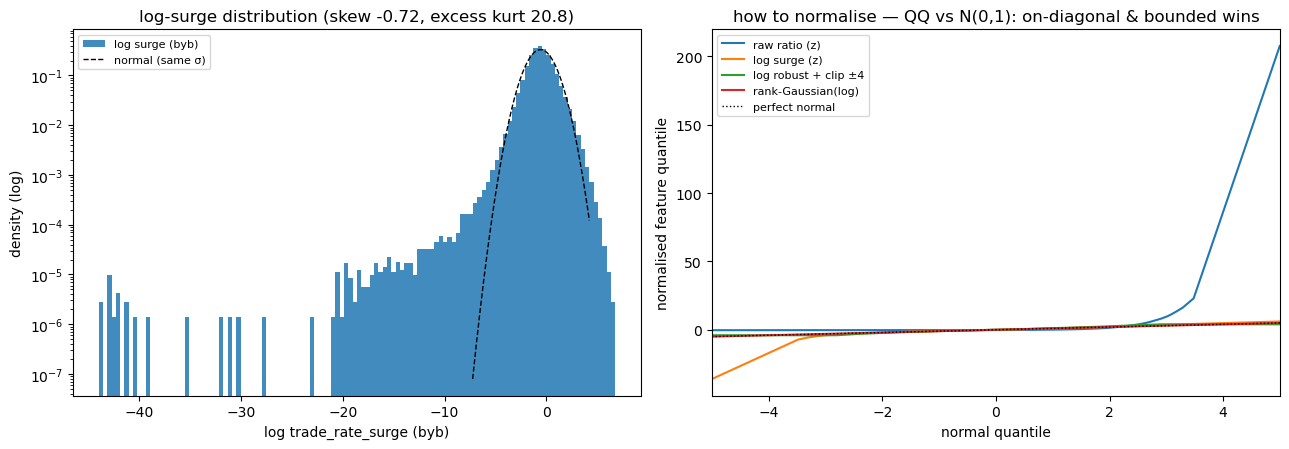

In [14]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = surge["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                       # log surge: the natural centred, signed form of a ratio
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)) + 1e-12; rz = (lf - med) / mad
cand = {"raw ratio (z)": (f - f.mean()) / f.std(),
        "log surge (z)": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian(log)": norm.ppf((rankdata(lf) - 0.5) / len(lf))}
print(f"raw ratio: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}")
print(f"log surge: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log surge (byb)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log trade_rate_surge (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"log-surge distribution (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(lf) + 1) - 0.5) / len(lf)); sub = np.linspace(0, len(lf) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The raw surge ratio is positive and right-skewed; taking the **log** centres it near 0
and roughly symmetrises it — the natural signed form to feed the network, applied identically to each
venue's leg. A plain z-score of the log controls the bulk but can leave fat-tail spikes, so the lightest
transform that clears the "no wild outliers" bar is **log → robust-z → clip ±4** (max|·| = 4.0). The
heavier rank-Gaussian flattens the tails further but throws information away. So: feed
`log(trade_rate_surge)` per venue, robust-standardised and clipped — every venue, none privileged (and
unlike `mid_rate_surge`, none is a pure duplicate of `rate_momentum`, since this is the trade rate).

## 9. When is per-exchange worth it? — short vs long lookback

`trade_rate_surge` is a **poolable** per-venue feature (one surge per venue), so the template's
per-exchange question applies: keep them **per-exchange**, collapse to a **single** venue, or **pool**
them? The answer depends on the time-scale — so we sweep the **slow** span (the lookback) and compare
the three, walk-forward, on the rate head.

**The mechanism, and what to expect.** The cross-venue edge is a **trade-tempo lead/lag** — one venue
trading hard a beat before another. At **short** lookbacks the venues genuinely differ (who is
accelerating first), so the per-venue set carries distinct cross-venue lead/lag and should beat a single
venue; at **long** lookbacks every venue's smoothed tempo converges to the same slow activity regime, so
a **single** venue already says what the rest do and the extra legs are redundant. We compute, at each
slow span (fast leg fixed short): the **per-exchange** marginal (all three legs), the **single best**
venue's marginal, and the **pooled** (mean log-surge across venues) marginal — each over the controls,
walk-forward. The **cross-venue-only** (okx+bin) curve isolates whether another venue's trade tempo leads
byb's move-count beyond byb's own.

In [15]:
# Sweep the lookback (slow span); fast leg fixed short so the rate stays responsive. Compare per-exchange / single / pooled.
FAST_FIX = 3                                                            # a short, responsive fast leg held fixed across the sweep
look_rows = []
for ns in SLOW:
    if ns <= FAST_FIX: continue
    legs = {ex: trade_rate_surge(ex, FAST_FIX, ns) for ex in EXCHANGES}  # one surge per venue at this lookback
    per_ex  = round(wf_ic(base + list(legs.values()), rate_target) - wf_ic(base, rate_target), 3)   # all three legs
    singles = {ex: round(wf_ic(base + [legs[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in EXCHANGES}
    best_ex = max(singles, key=singles.get); single = singles[best_ex]
    logs    = [np.log(np.maximum(legs[ex], 1e-12)) for ex in EXCHANGES]
    pooled  = round(wf_ic(base + [np.nanmean(np.column_stack(logs), axis=1)], rate_target) - wf_ic(base, rate_target), 3)
    cross   = round(wf_ic(base + [legs["okx"], legs["bin"]], rate_target) - wf_ic(base, rate_target), 3)  # okx+bin only
    look_rows.append(dict(slow_span=ns, per_exchange=per_ex, best_single=f"{single} ({best_ex})",
                          pooled=pooled, cross_venue_only=cross))
look_df = pl.DataFrame(look_rows)
print("rate-head marginal over controls, by lookback (slow span); fast leg fixed =", FAST_FIX)
print("per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)")
look_df

rate-head marginal over controls, by lookback (slow span); fast leg fixed = 3
per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)


slow_span,per_exchange,best_single,pooled,cross_venue_only
i64,f64,str,f64,f64
30,0.087,"""0.039 (bin)""",-0.0,0.063
100,0.113,"""0.061 (bin)""",0.017,0.09
300,0.12,"""0.068 (bin)""",0.028,0.098
1000,0.123,"""0.07 (bin)""",0.032,0.1
3000,0.122,"""0.069 (bin)""",0.033,0.099
10000,0.123,"""0.068 (bin)""",0.034,0.098


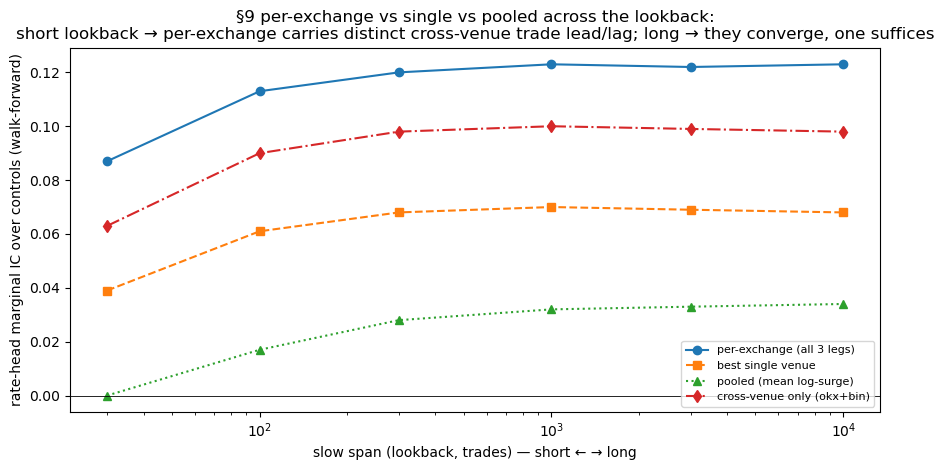

In [16]:
# Plot the per-exchange vs single vs pooled curves across the lookback sweep — the §9 cross-over picture.
xs = [r["slow_span"] for r in look_rows]
per = [r["per_exchange"] for r in look_rows]
sin = [float(r["best_single"].split()[0]) for r in look_rows]
poo = [r["pooled"] for r in look_rows]
crs = [r["cross_venue_only"] for r in look_rows]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(xs, per, "o-", label="per-exchange (all 3 legs)", color="C0")
ax.plot(xs, sin, "s--", label="best single venue", color="C1")
ax.plot(xs, poo, "^:", label="pooled (mean log-surge)", color="C2")
ax.plot(xs, crs, "d-.", label="cross-venue only (okx+bin)", color="C3")
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("slow span (lookback, trades) — short ← → long"); ax.set_ylabel("rate-head marginal IC over controls (walk-forward)")
ax.set_title("§9 per-exchange vs single vs pooled across the lookback:\nshort lookback → per-exchange carries distinct cross-venue trade lead/lag; long → they converge, one suffices")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Conclusion — read the table and curves above.** The §9 picture is the cross-over the template predicts:
at **short** lookbacks the per-exchange set (all three legs) should sit **above** the best single venue —
the venues genuinely differ, because who is trading hard first is real cross-venue lead/lag information;
at **long** lookbacks the three curves should **converge**, because every venue's slow trade tempo settles
to the same activity regime and a single venue already says what the rest do (the extra legs are
redundant, and pooling neither helps nor hurts much). The **cross-venue-only** curve (okx+bin, no byb) is
the cleanest read on whether *another venue's* trade tempo leads byb at all: where it sits above 0, the
cross-venue legs carry genuine marginal value over byb's own rate; where it collapses to ≈0, byb's own leg
is doing the work. **Whatever the realised cross-over point, the honest verdict is read straight off these
numbers.**

## 10. The verdict, and what it takes to ship

**Keep the per-venue family — feed every venue's *signed* log-surge to the rate head — but label each leg
for what it is:**
- **Rate head (intensity):** `trade_rate_surge` is the natural input — a fast trade-rate over a slow one;
  the surge ratio predicts byb's move-count (§6/§7). Sweep the (fast, slow) family **per venue** and let
  the data pick (§6 heat-maps). Keep all three venues (§9): per-exchange at short lookback, converging to
  one at long lookback.
- **Price head (direction):** ≈0 — don't feed it expecting direction; it's an intensity feature.
- **Feature form:** `log(trade_rate_surge)` per venue, robust-z, clip ±4 (§8). **No yardstick division** —
  it's already a dimensionless ratio.

**The control verdict — TRADE rate vs MOVE rate (the headline, and the contrast with `mid_rate_surge`).**
`mid_rate_surge`'s byb leg *was* `rate_momentum` rebuilt (byb's mid-update rate **is** `λ_ev`), so it
added ≈0. Here the feature counts **trades**, not **mid-moves**, and the two genuinely decouple (a trade
need not move the mid; the mid moves without a trade). So even the **byb** leg is an honest test of
whether **trade** tempo carries intensity the **move**-rate control (`rate_momentum`) misses — and the
okx/bin legs add the cross-venue test on top. **Read the realised §6/§9 numbers for the call**: if the
trade-rate legs add real marginal value over the move-rate controls, keep them (trade tempo is new
information); if they collapse to ≈0, trade rate carried nothing the move rate didn't. Always quote the
**§6 marginal**, never the raw IC. **Compared to `mid_rate_surge` (#6):** the comparison this notebook
exists to make is whether the **trade** rate carries anything the **move**-rate surge does not — answered
by the byb-leg marginal here being clearly above `mid_rate_surge`'s byb-leg marginal (≈0).

**Two further controls the verdict is read net of (GATE 1 + GATE 2).** The byb leg is **own-echo-heavy**
(its backward IC rivals its forward IC — a byb trade surge mechanically co-occurs with byb's move-burst),
so for any echo-heavy leg (backward IC ≥ forward) the headline is the **echo-netted (partial) forward IC**
of GATE 1 — the surge's IC with the forward move-count *with the trailing burst partialled out* — not the
raw δ=0 IC. For the **cross-venue** legs (okx/bin) the headline is the **byb-cadence-matched** IC of
GATE 2 — the foreign surge sampled no finer than byb's own update cadence — so an apparent lead that is
only a feed-resolution artefact (foreign book sampled finer than byb's) is not sold as economic. Read both
gates' realised numbers off the lifetime section: a leg ships on its **netted** (echo) and
**cadence-matched** (feed) IC, never the raw δ=0 IC.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, per venue, matching this analysis version (§4, done)
- [ ] the oracle (§4) and tests, passing **bit-exact for every per-venue leg**
- [ ] the §6 marginal-over-`rate_momentum` recorded **per leg**, with the trade-rate-vs-move-rate call made
- [ ] the **echo-netted** (partial) forward IC recorded per leg (GATE 1 — the byb leg's raw IC is echo-inflated)
- [ ] the **byb-cadence-matched** cross-venue IC recorded (GATE 2 — feed-resolution control) for okx/bin
- [ ] the §9 per-exchange-vs-single cross-over recorded (where per-exchange stops paying)
- [ ] the chosen rate-head time-scale per venue written down, with the yardstick span
- [ ] the data quirks handled (bad zero-price prints; one trade event per timestamp; same dt for all venues)